# 1. Data Collection: CoinDesk Headlines

This section describes the process used to collect cryptocurrency-related news articles from CoinDesk.  
The objective is to construct a dataset of time-stamped headlines that can be aligned with Bitcoin price data.

The approach uses CoinDesk’s sitemap infrastructure to retrieve article URLs, followed by webpage parsing to extract:
- Headline text
- Publication timestamp

To improve efficiency, parallel processing and checkpointing are implemented.

In [1]:
#Core web & parsing tools
import requests
from bs4 import BeautifulSoup

#Data handling
import pandas as pd

#Progress bars & timing
import time
from tqdm import tqdm

#Speed up scraping by running multiple requests at once
from concurrent.futures import ThreadPoolExecutor, as_completed

#For saving/resuming progress
import os

## 1.1 Configuration

Key parameters for scraping are defined below, including request settings, concurrency limits, and file paths.

In [2]:
#Pretend to be a normal browser (helps avoid blocks)
HEADERS = {"User-Agent": "Mozilla/5.0 (academic-research)"}

#How long to wait before giving up on a webpage
TIMEOUT = 30

#How many pages to request at the same time
#If I get timeouts / failures, reduce to 5
MAX_WORKERS = 8

#Only keep articles from this date onward
MIN_DATE = "2021-01-01"

#CoinDesk sitemap index (this lists all their sitemap files)
SITEMAP_INDEX = "https://www.coindesk.com/sitemap-index.xml"

#Output files (saved to my folder) 
OUT_ALL_URLS = "coindesk_article_urls_all.csv"
OUT_FILTERED_URLS = "coindesk_bitcoin_article_urls_2021_present.csv"
OUT_CHECKPOINT = "coindesk_checkpoint_rows.csv"
OUT_FINAL = "coindesk_bitcoin_headlines_2021_present.csv"

## 1.2 Retrieve Article URLs

CoinDesk provides sitemap files containing links to all published articles.  
These are used as the primary source for URL extraction.

Only article-related sitemap files are retained, excluding static and tag pages.

In [3]:
def get_sitemap_urls():
    r = requests.get(SITEMAP_INDEX, headers=HEADERS, timeout=TIMEOUT)
    r.raise_for_status()  #stops with error if request failed
    soup = BeautifulSoup(r.text, "xml")
    return [loc.text.strip() for loc in soup.find_all("loc")]

def extract_urls_from_sitemap(sm_url):
    try:
        r = requests.get(sm_url, headers=HEADERS, timeout=TIMEOUT)
        if r.status_code != 200:
            return []

        sm = BeautifulSoup(r.text, "xml")

        rows = []
        for url_tag in sm.find_all("url"):
            loc = url_tag.find("loc")
            lastmod = url_tag.find("lastmod")

            if loc:
                rows.append({
                    "url": loc.text.strip(),
                    "lastmod": lastmod.text.strip() if lastmod else None
                })

        return rows
    except:
        return []


sitemap_urls = get_sitemap_urls()
article_sitemaps = [u for u in sitemap_urls if "/sitemaps/articles-" in u]

all_rows = []
for sm in tqdm(article_sitemaps):
    all_rows.extend(extract_urls_from_sitemap(sm))
    time.sleep(0.05)

df_urls = pd.DataFrame(all_rows)
df_urls.to_csv(OUT_ALL_URLS, index=False)

100%|███████████████████████████████████████████████████████████████████████████████████| 19/19 [00:29<00:00,  1.56s/it]


## 1.3 Filter Relevant Articles

Articles are filtered to include only those published from 2021 onwards.  
No keyword-based filtering is applied at this stage to avoid excluding relevant content.

This ensures broader coverage and allows the model to learn relevance from text.

In [4]:
df_urls = pd.read_csv(OUT_ALL_URLS)

df_urls["lastmod"] = pd.to_datetime(df_urls["lastmod"], utc=True, errors="coerce")

df_filtered = df_urls[df_urls["lastmod"] >= MIN_DATE].copy()

df_filtered.to_csv(OUT_FILTERED_URLS, index=False)

print("Filtered URLs:", len(df_filtered))

Filtered URLs: 9342


## 1.4 Parse Article Content

Each article page is visited and parsed to extract:
- Headline text
- Publication timestamp

Multiple timestamp formats are supported to improve coverage across different page structures.

In [5]:
session = requests.Session()
session.headers.update(HEADERS)

def parse_article(url):
    try:
        r = session.get(url, timeout=TIMEOUT)
        if r.status_code != 200:
            return None

        soup = BeautifulSoup(r.text, "html.parser")

        #Extract headline
        og = soup.find("meta", {"property": "og:title"})
        headline = og.get("content").strip() if og and og.get("content") else None

        def meta(name, prop=False):
            tag = soup.find("meta", {"property": name}) if prop else soup.find("meta", {"name": name})
            return tag.get("content").strip() if tag and tag.get("content") else None

        #Primary format
        date_str = meta("publish_date") or meta("display_date")
        time_str = meta("publish_time") or meta("display_time")

        if date_str and time_str:
            published = f"{date_str} {time_str}"
        else:
            #Fallback ISO format
            published = (
                meta("article:published_time", prop=True)
                or meta("og:updated_time", prop=True)
            )

        if headline and published:
            return {"headline": headline, "published": published, "link": url}

        return None

    except:
        return None

## 1.5 Scraping with Checkpointing

To handle large volumes of URLs, scraping is performed in parallel.  
Checkpointing is used to periodically save progress and allow resumption in case of interruption.

In [6]:
urls = pd.read_csv(OUT_FILTERED_URLS)["url"].tolist()

rows = []
done = set()

if os.path.exists(OUT_CHECKPOINT):
    ck = pd.read_csv(OUT_CHECKPOINT)
    rows = ck.to_dict("records")
    done = set(ck["link"])

todo = [u for u in urls if u not in done]

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    futures = {ex.submit(parse_article, u): u for u in todo}

    for i, fut in enumerate(tqdm(as_completed(futures), total=len(futures))):
        res = fut.result()
        if res:
            rows.append(res)

        if i % 300 == 0:
            pd.DataFrame(rows).to_csv(OUT_CHECKPOINT, index=False)

pd.DataFrame(rows).to_csv(OUT_CHECKPOINT, index=False)

100%|█████████████████████████████████████████████████████████████████████████████████| 786/786 [00:31<00:00, 25.12it/s]


## 1.6 Data Cleaning

The scraped dataset is cleaned by:
- Converting timestamps to UTC datetime
- Removing invalid or missing values
- Eliminating duplicate entries
- Sorting chronologically

In [7]:
df = pd.DataFrame(rows)

df["published"] = pd.to_datetime(df["published"], utc=True, errors="coerce")

df = df.dropna(subset=["published"])

df = df.drop_duplicates(subset=["headline", "published", "link"])

df = df.sort_values("published").reset_index(drop=True)

df.to_csv(OUT_FINAL, index=False)

print("Final size:", len(df))

Final size: 1424


# 2. Data Collection: Binance BTC Price Data

Bitcoin price data is collected from Binance at a 1-minute resolution.  
This provides a high-frequency time series used to compute short-term returns.

In [8]:
import requests
import pandas as pd
from datetime import datetime, timezone
import time

BINANCE_KLINES = "https://api.binance.com/api/v3/klines"

SYMBOL = "BTCUSDT"
INTERVAL = "1m"

START_DATE = "2021-01-01"
OUT_BTC_1M = "btc_1m.csv"

## 2.1 Download 1-Minute Price Data

Data is retrieved in batches due to API limits.  
Pagination is used to iteratively download the full time series.

In [9]:
def to_millis(dt):
    dt = datetime.strptime(dt, "%Y-%m-%d").replace(tzinfo=timezone.utc)
    return int(dt.timestamp() * 1000)

start_ms = to_millis(START_DATE)

all_data = []

while True:
    params = {
        "symbol": SYMBOL,
        "interval": INTERVAL,
        "startTime": start_ms,
        "limit": 1000
    }

    r = requests.get(BINANCE_KLINES, params=params)
    data = r.json()

    if not data:
        break

    df_chunk = pd.DataFrame(data)
    df_chunk[0] = pd.to_datetime(df_chunk[0], unit="ms", utc=True)

    all_data.append(df_chunk)

    start_ms = int(df_chunk[0].iloc[-1].value / 1e6) + 60000

    time.sleep(0.2)

df_prices = pd.concat(all_data)
df_prices = df_prices.rename(columns={0: "time", 4: "close"})
df_prices = df_prices[["time", "close"]]

df_prices.to_csv(OUT_BTC_1M, index=False)

ConnectionError: HTTPSConnectionPool(host='api.binance.com', port=443): Max retries exceeded with url: /api/v3/klines?symbol=BTCUSDT&interval=1m&startTime=1613423940000&limit=1000 (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x14ea8f4d0>: Failed to establish a new connection: [Errno 51] Network is unreachable'))

# 3. Data Quality Check

The integrity of the time series is verified by checking for missing intervals.  
Minor gaps are expected and are handled during label construction.

In [ ]:
df = df_prices.copy().sort_values("time")

diffs = df["time"].diff().dropna()
print(diffs.value_counts().head())

gaps = df[df["time"].diff() != pd.Timedelta(minutes=1)]
print(gaps.head())

Prior to merging, both datasets were validated to ensure consistency, completeness, and temporal alignment.

Key checks included:
- Dataset size
- Date coverage
- Missing values

This step ensures that the datasets are suitable for time-based merging and label construction.


In [ ]:
#Load headlines
df_news = pd.read_csv(OUT_FINAL)
df_news["published"] = pd.to_datetime(df_news["published"], utc=True)

#Load BTC prices
df_prices = pd.read_csv(OUT_BTC_1M)
df_prices["time"] = pd.to_datetime(df_prices["time"], utc=True)

In [ ]:
#Headlines dataset summary
print("HEADLINES DATASET")
print("Rows:", len(df_news))
print("Date range:", df_news["published"].min(), "→", df_news["published"].max())
print("Missing values:\n", df_news.isna().sum())

print("\n" + "="*50 + "\n")

#BTC dataset summary
print("BTC PRICE DATASET")
print("Rows:", len(df_prices))
print("Date range:", df_prices["time"].min(), "→", df_prices["time"].max())
print("Missing values:\n", df_prices.isna().sum())

# 4. Data Merging & Label Construction

This section aligns CoinDesk headlines with Bitcoin price data and constructs the prediction target.

Each headline is treated as a market-relevant event and mapped to the next available Bitcoin price.  
This ensures that only information available at the time of the event is used.

The primary target variable is defined as the 1-hour forward return:

return_1h = (price_{t+60} - price_t) / price_t

A binary classification label is also created:
- up_1h = 1 if return > 0
- up_1h = 0 otherwise

This formulation avoids lookahead bias and reflects a realistic prediction setting.

## 4.1 Load Datasets

The cleaned headline dataset and 1-minute Bitcoin price data are loaded and prepared for merging.

In [ ]:
#Load headlines
df_news = pd.read_csv(OUT_FINAL)
df_news["published"] = pd.to_datetime(df_news["published"], utc=True)

#Load BTC prices
df_prices = pd.read_csv(OUT_BTC_1M)
df_prices["time"] = pd.to_datetime(df_prices["time"], utc=True)

#Sort both datasets (required for time-based merging)
df_news = df_news.sort_values("published")
df_prices = df_prices.sort_values("time")

print("News rows:", len(df_news))
print("Price rows:", len(df_prices))

## 4.2 Time Alignment

Each headline is aligned with the first available Bitcoin price at or after its publication time.

A forward merge is used to ensure:
- Prices occur after the news event
- No future information is used

This step is critical to avoid lookahead bias.

In [ ]:
#Align each headline to the next available BTC price
df_merged = pd.merge_asof(
    df_news,
    df_prices,
    left_on="published",
    right_on="time",
    direction="forward"  #ensures no future leakage
)

#Rename for clarity
df_merged = df_merged.rename(columns={"close": "price_t"})

## 4.3 Compute Future Price (t + 60 minutes)

To calculate the 1-hour return, the Bitcoin price 60 minutes after the event is required.

In [ ]:
#Create future price column in BTC data
df_prices["price_t_plus_60"] = df_prices["close"].shift(-60)

## 4.4 Align Future Price with Headlines

The future price is merged using the same time alignment logic.

In [ ]:
#Merge future price
df_merged = pd.merge_asof(
    df_merged,
    df_prices[["time", "price_t_plus_60"]],
    left_on="published",
    right_on="time",
    direction="forward"
)

## 4.5 Construct Target Variables

The 1-hour return and binary classification label are computed.

In [ ]:
#Compute return
df_merged["return_1h"] = (
    df_merged["price_t_plus_60"] - df_merged["price_t"]
) / df_merged["price_t"]

#Binary classification target
df_merged["up_1h"] = (df_merged["return_1h"] > 0).astype(int)

## 4.6 Remove Incomplete Rows

Rows near the end of the dataset may not have a future price available.
These are removed to ensure valid label construction.

In [ ]:
#Drop rows where future price is missing
df_merged = df_merged.dropna(subset=["price_t", "price_t_plus_60"])

## 4.7 Final Dataset Validation

Basic checks are performed to verify correctness of the merged dataset.

In [ ]:
print("Final dataset shape:", df_merged.shape)

print("\nSample rows:")
print(df_merged[["published", "price_t", "price_t_plus_60", "return_1h", "up_1h"]].head())

print("\nReturn distribution:")
print(df_merged["return_1h"].describe())

print("\nClass balance:")
print(df_merged["up_1h"].value_counts(normalize=True))

# 5. Dataset Validation & Visualisation

## 5.1 Return Distribution

This plot shows the distribution of 1-hour Bitcoin returns following cryptocurrency-related news events.

The purpose of this visualisation is to confirm that the calculated returns are realistic and centred around zero, as expected in a short-horizon financial prediction setting.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df_merged["return_1h"], bins=50)

plt.title("Distribution of 1-Hour Bitcoin Returns")
plt.xlabel("1-Hour Return")
plt.ylabel("Frequency")

plt.show()

## 5.2 Class Balance

This plot shows the balance between upward and downward Bitcoin price movements over the 1-hour prediction horizon.

A balanced target distribution is important because it prevents the classification task from being dominated by a single class.

In [ ]:
plt.figure(figsize=(6,5))

df_merged["up_1h"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Up vs Down Labels")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks([0,1], ["Down (0)", "Up (1)"], rotation=0)

plt.show()

## 5.3 1-Hour Returns Over Time

This visualisation shows how the calculated 1-hour Bitcoin returns vary over time across the dataset period.

The purpose of this plot is to inspect overall market variability and identify whether any abnormal spikes or structural issues exist in the constructed labels.

In [ ]:
plt.figure(figsize=(12,6))

df_merged = df_merged.sort_values("published")

plt.plot(df_merged["published"], df_merged["return_1h"])

plt.title("1-Hour Bitcoin Returns Over Time")
plt.xlabel("Publication Time")
plt.ylabel("1-Hour Return")

plt.show()

## 5.4 Save Final Dataset

The completed merged dataset is saved for later modelling and evaluation.

In [ ]:
#Remove temporary merge columns
df_merged = df_merged.drop(columns=["time_x", "time_y"])

#Save final dataset
df_merged.to_csv("final_btc_news_dataset.csv", index=False)

print("Final dataset saved successfully.")

# 6. Baseline Models & Evaluation

## 6.1 Load Final Dataset

In this section, I load the final merged dataset created during the previous stage of the project.

The dataset contains:
- cryptocurrency-related news headlines
- publication timestamps
- Bitcoin prices at the time of publication
- 1-hour future Bitcoin returns
- binary direction labels (`up_1h`)

The purpose of this section is to prepare the dataset for baseline modelling and evaluation.

In [10]:
import pandas as pd

#Load the completed merged dataset
df = pd.read_csv("final_btc_news_dataset.csv")

#Convert publication timestamps back to datetime
df["published"] = pd.to_datetime(df["published"], utc=True)

#Display basic information
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isna().sum())

Dataset shape: (1190, 7)

Columns:
Index(['headline', 'published', 'link', 'price_t', 'price_t_plus_60',
       'return_1h', 'up_1h'],
      dtype='object')

First 5 rows:
                                            headline  \
0  Samourai Wallet’s Lawyers Say Prosecution Supp...   
1  Staking Firm Figment Is on the Hunt for $100M-...   
2  Crypto Price Wrap: Bitcoin (BTC) Dominance Soa...   
3  Strive Goes Public Via Merger With Asset Entit...   
4  The Protocol: Ethereum’s Pectra Upgrade Finall...   

                  published  \
0 2025-05-05 18:37:00+00:00   
1 2025-05-06 08:12:00+00:00   
2 2025-05-06 21:04:00+00:00   
3 2025-05-07 18:11:00+00:00   
4 2025-05-07 19:29:00+00:00   

                                                link   price_t  \
0  https://www.coindesk.com/policy/2025/05/05/sam...  94889.99   
1  https://www.coindesk.com/markets/2025/05/06/fi...  94265.49   
2  https://www.coindesk.com/markets/2025/05/06/bi...  94799.98   
3  https://www.coindesk.com/business/202

## 6.2 Time-Based Train/Test Split

Because financial and news data are temporal in nature, I used a chronological train/test split rather than randomly shuffling observations.

This approach better reflects a real-world forecasting setting, where models are trained using historical data and evaluated on future unseen events.

The earliest 80% of observations were used for training, while the most recent 20% were reserved for testing.

This helps prevent temporal leakage and ensures that future information does not influence the training process.

In [11]:
#Sort dataset chronologically
df = df.sort_values("published").reset_index(drop=True)

#Define input features and target labels
X = df["headline"]
y = df["up_1h"]

#Create chronological split index (80% train / 20% test)
split_index = int(len(df) * 0.8)

#Training data = earliest 80%
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

#Test data = latest 20%
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

#Display split information
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining date range:")
print(df.iloc[:split_index]["published"].min(), "→",
      df.iloc[:split_index]["published"].max())

print("\nTest date range:")
print(df.iloc[split_index:]["published"].min(), "→",
      df.iloc[split_index:]["published"].max())

Training samples: 952
Test samples: 238

Training date range:
2025-05-05 18:37:00+00:00 → 2026-04-23 18:35:00+00:00

Test date range:
2026-04-23 20:52:00+00:00 → 2026-05-05 17:27:00+00:00


## 6.3 Random Baseline

As an initial benchmark, I implemented a random baseline classifier.

This baseline generates random up/down predictions and represents the minimum expected predictive performance for the task.

The purpose of this experiment is to determine whether later models are capable of outperforming chance-level prediction.

In [12]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

#Set seed for reproducibility
np.random.seed(42)

#Generate random predictions (0 or 1)
random_preds = np.random.randint(0, 2, size=len(y_test))

#Generate random probabilities for ROC-AUC
random_probs = np.random.rand(len(y_test))

#Evaluate random baseline
random_accuracy = accuracy_score(y_test, random_preds)
random_f1 = f1_score(y_test, random_preds)
random_auc = roc_auc_score(y_test, random_probs)

#Display results
print("Random Baseline Results")
print("------------------------")

print(f"Accuracy: {random_accuracy:.4f}")
print(f"F1 Score: {random_f1:.4f}")
print(f"ROC-AUC:  {random_auc:.4f}")

Random Baseline Results
------------------------
Accuracy: 0.4664
F1 Score: 0.4549
ROC-AUC:  0.5212


## 6.4 Majority Class Baseline

A majority class baseline was implemented as a simple deterministic benchmark.

This classifier always predicts the most common class observed in the training data.

The purpose of this baseline is to determine whether later machine learning models can outperform a naive prediction strategy.

In [13]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

#Find majority class from training data
majority_class = y_train.mode()[0]

print("Majority class:", majority_class)

#Predict majority class for every test observation
majority_preds = np.full(len(y_test), majority_class)

#Since predictions are constant, probabilities are also constant
majority_probs = np.full(len(y_test), majority_class)

#Evaluate majority baseline
majority_accuracy = accuracy_score(y_test, majority_preds)
majority_f1 = f1_score(y_test, majority_preds)
majority_auc = roc_auc_score(y_test, majority_probs)

#Display results
print("\nMajority Baseline Results")
print("--------------------------")

print(f"Accuracy: {majority_accuracy:.4f}")
print(f"F1 Score: {majority_f1:.4f}")
print(f"ROC-AUC:  {majority_auc:.4f}")

Majority class: 1

Majority Baseline Results
--------------------------
Accuracy: 0.4748
F1 Score: 0.6439
ROC-AUC:  0.5000


## 6.5 TF-IDF Feature Extraction

Before training a machine learning model, the headline text must be converted into numerical features.

To achieve this, I used Term Frequency–Inverse Document Frequency (TF-IDF) vectorisation.

TF-IDF converts text into weighted numerical vectors based on the importance of words within the dataset. Words that appear frequently within a specific headline but less frequently across the overall corpus receive higher importance scores.

This approach provides a simple and interpretable baseline representation for financial news headlines.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Create TF-IDF vectoriser
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

#Learn vocabulary from training data and transform headlines into vectors
X_train_tfidf = tfidf.fit_transform(X_train)

#Transform test headlines using same vocabulary
X_test_tfidf = tfidf.transform(X_test)

#Display matrix shapes
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (952, 2940)
Test TF-IDF shape: (238, 2940)


## 6.6 Logistic Regression Baseline Model

A logistic regression classifier was trained using TF-IDF headline representations.

Logistic regression is a widely used baseline model in natural language processing due to its interpretability, efficiency, and strong performance on sparse text data.

The model attempts to learn relationships between headline wording and the direction of future Bitcoin price movement over the following one-hour period.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

#Create logistic regression model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

#Train model on TF-IDF features
model.fit(X_train_tfidf, y_train)

#Generate predictions
lr_preds = model.predict(X_test_tfidf)

#Generate prediction probabilities
lr_probs = model.predict_proba(X_test_tfidf)[:, 1]

#Evaluate model
lr_accuracy = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_probs)

#Display results
print("Logistic Regression Results")
print("----------------------------")

print(f"Accuracy: {lr_accuracy:.4f}")
print(f"F1 Score: {lr_f1:.4f}")
print(f"ROC-AUC:  {lr_auc:.4f}")

Logistic Regression Results
----------------------------
Accuracy: 0.5168
F1 Score: 0.5756
ROC-AUC:  0.5204


## 6.7 Baseline Model Comparison

The performance of all baseline models was compared using accuracy, F1 score, and ROC-AUC metrics.

This comparison allows evaluation of whether NLP-based modelling provides meaningful improvement over naive prediction strategies.

In [16]:
results = pd.DataFrame({
    "Model": [
        "Random Baseline",
        "Majority Baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        random_accuracy,
        majority_accuracy,
        lr_accuracy
    ],
    "F1 Score": [
        random_f1,
        majority_f1,
        lr_f1
    ],
    "ROC-AUC": [
        random_auc,
        majority_auc,
        lr_auc
    ]
})

#Round values for readability
results = results.round(4)

print(results)

                 Model  Accuracy  F1 Score  ROC-AUC
0      Random Baseline    0.4664    0.4549   0.5212
1    Majority Baseline    0.4748    0.6439   0.5000
2  Logistic Regression    0.5168    0.5756   0.5204


## 6.8 Accuracy Comparison Across Baseline Models

The following figure compares classification accuracy across all baseline models.

This allows visual comparison of whether NLP-based modelling improved predictive performance beyond naive benchmark strategies.

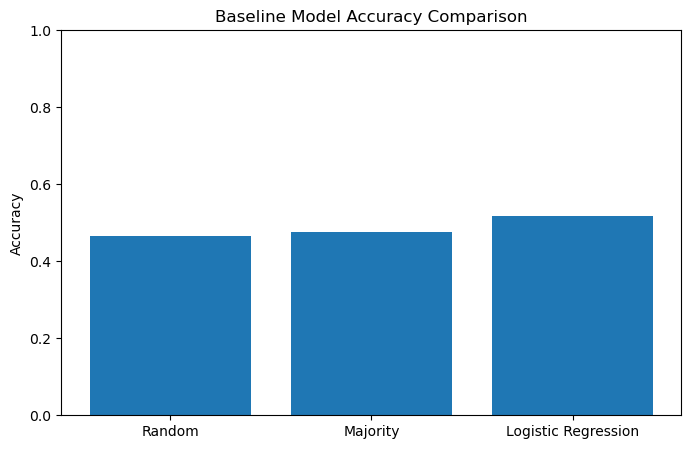

In [17]:
import matplotlib.pyplot as plt

models = [
    "Random",
    "Majority",
    "Logistic Regression"
]

accuracies = [
    random_accuracy,
    majority_accuracy,
    lr_accuracy
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Baseline Model Accuracy Comparison")

plt.ylim(0, 1)

plt.show()

## 6.9 ROC-AUC Comparison

The following figure compares ROC-AUC scores across all baseline models.

ROC-AUC measures a model’s ability to discriminate between upward and downward Bitcoin price movements across different classification thresholds.

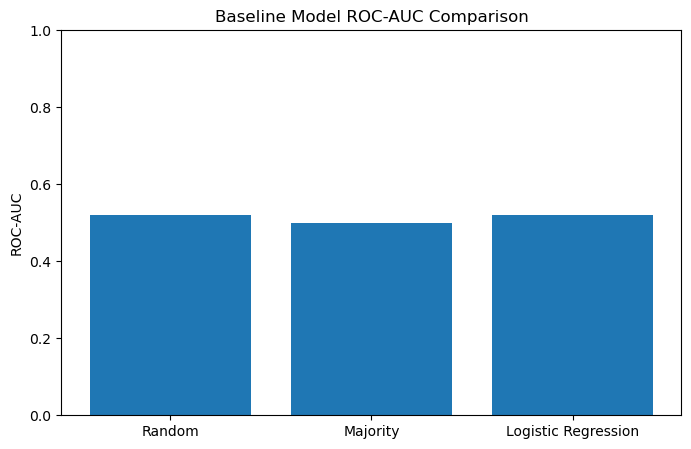

In [18]:
auc_scores = [
    random_auc,
    majority_auc,
    lr_auc
]

plt.figure(figsize=(8, 5))
plt.bar(models, auc_scores)

plt.ylabel("ROC-AUC")
plt.title("Baseline Model ROC-AUC Comparison")

plt.ylim(0, 1)

plt.show()

## 6.10 Distribution of Target Classes

The following figure shows the distribution of upward and downward Bitcoin price movements within the dataset.

This provides insight into class balance and helps contextualise baseline model performance.

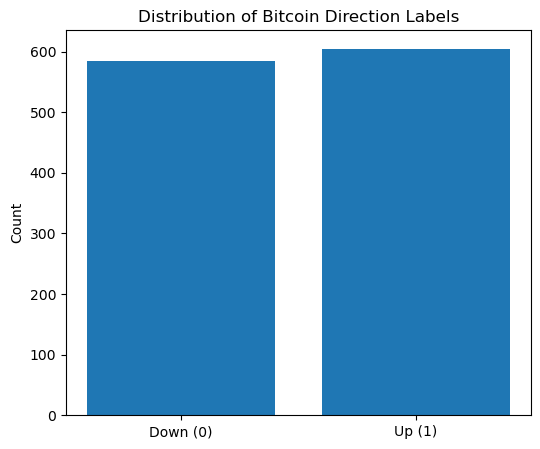

In [19]:
class_counts = df["up_1h"].value_counts().sort_index()

labels = ["Down (0)", "Up (1)"]

plt.figure(figsize=(6, 5))
plt.bar(labels, class_counts.values)

plt.ylabel("Count")
plt.title("Distribution of Bitcoin Direction Labels")

plt.show()

# 7. Stronger Models

This section explores stronger modelling approaches beyond the TF-IDF logistic regression baseline developed previously.

The goal is to determine whether finance-specific semantic representations and more advanced machine learning methods can improve predictive performance for short-term Bitcoin price direction.

## 7.1 FinBERT Sentiment Extraction

TF-IDF representations capture word frequency but do not understand semantic meaning or financial sentiment.

To address this limitation, I used FinBERT, a transformer model pretrained specifically on financial text.

FinBERT was used to generate sentiment predictions for each cryptocurrency headline. These sentiment scores were then used as features for downstream classification models.

In [20]:
!pip install transformers torch --quiet

## 7.2 Load FinBERT Model

The pretrained FinBERT model was loaded using the Hugging Face Transformers library.

FinBERT is a transformer-based language model trained specifically on financial text and financial sentiment tasks.

The model predicts:
- positive sentiment
- negative sentiment
- neutral sentiment

for each headline.

In [21]:
from transformers import pipeline

#Load pretrained FinBERT sentiment pipeline
finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert"
)

print("FinBERT loaded successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded successfully.


## 7.3 Initial FinBERT Testing

Before applying FinBERT to the full dataset, I tested the model on a small sample of cryptocurrency headlines to verify that the sentiment predictions were reasonable and financially meaningful.

In [22]:
#Reload final dataset
import pandas as pd

df = pd.read_csv("final_btc_news_dataset.csv")

print("Dataset loaded:", df.shape)
print(df.head())

Dataset loaded: (1190, 7)
                                            headline  \
0  Samourai Wallet’s Lawyers Say Prosecution Supp...   
1  Staking Firm Figment Is on the Hunt for $100M-...   
2  Crypto Price Wrap: Bitcoin (BTC) Dominance Soa...   
3  Strive Goes Public Via Merger With Asset Entit...   
4  The Protocol: Ethereum’s Pectra Upgrade Finall...   

                   published  \
0  2025-05-05 18:37:00+00:00   
1  2025-05-06 08:12:00+00:00   
2  2025-05-06 21:04:00+00:00   
3  2025-05-07 18:11:00+00:00   
4  2025-05-07 19:29:00+00:00   

                                                link   price_t  \
0  https://www.coindesk.com/policy/2025/05/05/sam...  94889.99   
1  https://www.coindesk.com/markets/2025/05/06/fi...  94265.49   
2  https://www.coindesk.com/markets/2025/05/06/bi...  94799.98   
3  https://www.coindesk.com/business/2025/05/07/s...  96032.96   
4  https://www.coindesk.com/tech/2025/05/07/the-p...  96007.95   

   price_t_plus_60  return_1h  up_1h  
0       

In [23]:
sample_headlines = df["headline"].head(5).tolist()

results = finbert(sample_headlines)

for headline, result in zip(sample_headlines, results):
    print("\nHEADLINE:")
    print(headline)

    print("PREDICTION:")
    print(result)


HEADLINE:
Samourai Wallet’s Lawyers Say Prosecution Suppressed Critical Evidence, Call for Dismissal
PREDICTION:
{'label': 'negative', 'score': 0.7600449323654175}

HEADLINE:
Staking Firm Figment Is on the Hunt for $100M- $200M Takeover Opportunities
PREDICTION:
{'label': 'neutral', 'score': 0.9176124930381775}

HEADLINE:
Crypto Price Wrap: Bitcoin (BTC) Dominance Soars Ahead of FOMC as Volatility ‘Burst’ Looms
PREDICTION:
{'label': 'positive', 'score': 0.8153783082962036}

HEADLINE:
Strive Goes Public Via Merger With Asset Entities (ASST) to Launch Bitcoin (BTC) Treasury Strategy
PREDICTION:
{'label': 'neutral', 'score': 0.904597818851471}

HEADLINE:
The Protocol: Ethereum’s Pectra Upgrade Finally Goes Live
PREDICTION:
{'label': 'neutral', 'score': 0.8264185190200806}


## 7.4 Full FinBERT Sentiment Extraction

After validating the model on a small sample of headlines, FinBERT sentiment predictions were generated for the full dataset.

For each headline, the model produced:
- predicted sentiment label
- confidence score

These outputs were later used as predictive features for downstream classification models.

In [24]:
#Run FinBERT on every headline
sentiment_results = finbert(
    df["headline"].tolist(),
    truncation=True
)

#Extract sentiment labels
df["finbert_label"] = [r["label"] for r in sentiment_results]

#Extract confidence scores
df["finbert_score"] = [r["score"] for r in sentiment_results]

print("FinBERT sentiment extraction complete.")

print("\nSentiment distribution:")
print(df["finbert_label"].value_counts())

print("\nFirst 5 rows:")
print(df[["headline", "finbert_label", "finbert_score"]].head())

FinBERT sentiment extraction complete.

Sentiment distribution:
finbert_label
neutral     502
positive    351
negative    337
Name: count, dtype: int64

First 5 rows:
                                            headline finbert_label  \
0  Samourai Wallet’s Lawyers Say Prosecution Supp...      negative   
1  Staking Firm Figment Is on the Hunt for $100M-...       neutral   
2  Crypto Price Wrap: Bitcoin (BTC) Dominance Soa...      positive   
3  Strive Goes Public Via Merger With Asset Entit...       neutral   
4  The Protocol: Ethereum’s Pectra Upgrade Finall...       neutral   

   finbert_score  
0       0.760045  
1       0.917612  
2       0.815378  
3       0.904598  
4       0.826419  


## 7.5 Sentiment Feature Engineering

The categorical FinBERT sentiment outputs were converted into numerical representations suitable for machine learning models.

This allowed the sentiment information extracted by the transformer model to be used as predictive features for Bitcoin price direction classification.

In [25]:
#Convert sentiment labels into numerical form
sentiment_map = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

df["finbert_sentiment"] = df["finbert_label"].map(sentiment_map)

print(df[[
    "headline",
    "finbert_label",
    "finbert_sentiment",
    "finbert_score"
]].head())

                                            headline finbert_label  \
0  Samourai Wallet’s Lawyers Say Prosecution Supp...      negative   
1  Staking Firm Figment Is on the Hunt for $100M-...       neutral   
2  Crypto Price Wrap: Bitcoin (BTC) Dominance Soa...      positive   
3  Strive Goes Public Via Merger With Asset Entit...       neutral   
4  The Protocol: Ethereum’s Pectra Upgrade Finall...       neutral   

   finbert_sentiment  finbert_score  
0                 -1       0.760045  
1                  0       0.917612  
2                  1       0.815378  
3                  0       0.904598  
4                  0       0.826419  


## 7.6 FinBERT-Based Classification Model

The sentiment features extracted using FinBERT were used to train a logistic regression classifier.

The goal was to evaluate whether transformer-derived financial sentiment information could improve prediction performance compared to the earlier TF-IDF baseline model.

In [26]:
#Prepare FinBERT features
from sklearn.model_selection import train_test_split

#Features
X = df[["finbert_sentiment", "finbert_score"]]

#Target
y = df["up_1h"]

#Time-based split (same as Week 2)
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 952
Test samples: 238


In [27]:

#Train FinBERT-based logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

#Train classifier
finbert_model = LogisticRegression()

finbert_model.fit(X_train, y_train)

#Predictions
y_pred = finbert_model.predict(X_test)
y_prob = finbert_model.predict_proba(X_test)[:, 1]

#Metrics
finbert_accuracy = accuracy_score(y_test, y_pred)
finbert_f1 = f1_score(y_test, y_pred)
finbert_roc_auc = roc_auc_score(y_test, y_prob)

print("FinBERT Model Results")
print("------------------------")
print("Accuracy:", round(finbert_accuracy, 4))
print("F1 Score:", round(finbert_f1, 4))
print("ROC-AUC: ", round(finbert_roc_auc, 4))

FinBERT Model Results
------------------------
Accuracy: 0.4874
F1 Score: 0.6164
ROC-AUC:  0.443


## 7.7 Model Comparison

The FinBERT-based sentiment model was compared against the baseline models developed previously.

This comparison evaluates whether transformer-derived financial sentiment features provide additional predictive value for short-term Bitcoin price movement prediction.

In [33]:
comparison_df = pd.DataFrame({
    "Model": [
        "Random Baseline",
        "Majority Baseline",
        "TF-IDF Logistic Regression",
        "FinBERT Sentiment Model",
        "XGBoost + FinBERT Features"
    ],
    "Accuracy": [
        random_accuracy,
        majority_accuracy,
        lr_accuracy,
        finbert_accuracy,
        xgb_accuracy
    ],
    "F1 Score": [
        random_f1,
        majority_f1,
        lr_f1,
        finbert_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        random_auc,
        majority_auc,
        lr_auc,
        finbert_roc_auc,
        xgb_auc
    ]
})

comparison_df = comparison_df.round(4)

print(comparison_df)

                        Model  Accuracy  F1 Score  ROC-AUC
0             Random Baseline    0.4664    0.4549   0.5212
1           Majority Baseline    0.4748    0.6439   0.5000
2  TF-IDF Logistic Regression    0.5168    0.5756   0.5204
3     FinBERT Sentiment Model    0.4874    0.6164   0.4430
4  XGBoost + FinBERT Features    0.5546    0.5508   0.5392


## 7.8 XGBoost Classification Model

To explore whether a stronger machine learning algorithm could better utilise the transformer-derived sentiment features, an XGBoost classifier was implemented.

XGBoost is an ensemble boosting algorithm capable of modelling non-linear relationships and feature interactions more effectively than logistic regression.

In [31]:
!pip install xgboost --quiet

## 7.9 Training the XGBoost Model

The XGBoost classifier was trained using the FinBERT-derived sentiment features.

The same time-based train/test split used in previous experiments was maintained to ensure consistency and prevent temporal data leakage.

In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

#Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

#Train model
xgb_model.fit(X_train, y_train)

#Generate predictions
xgb_preds = xgb_model.predict(X_test)

#Generate probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

#Evaluate performance
xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)
xgb_auc = roc_auc_score(y_test, xgb_probs)

#Display results
print("XGBoost Results")
print("----------------------")

print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"F1 Score: {xgb_f1:.4f}")
print(f"ROC-AUC:  {xgb_auc:.4f}")

XGBoost Results
----------------------
Accuracy: 0.5546
F1 Score: 0.5508
ROC-AUC:  0.5392


In [34]:
comparison_df.to_csv("week3_model_comparison.csv", index=False)

In [35]:
df.to_csv("final_btc_news_dataset_with_finbert.csv", index=False)

# 8. Week 3 Visualisations

This section visualises the comparative performance of the implemented machine learning models and explores the distribution of FinBERT-derived sentiment classifications.

## 8.1 Model Accuracy Comparison

This figure compares classification accuracy across all implemented models.

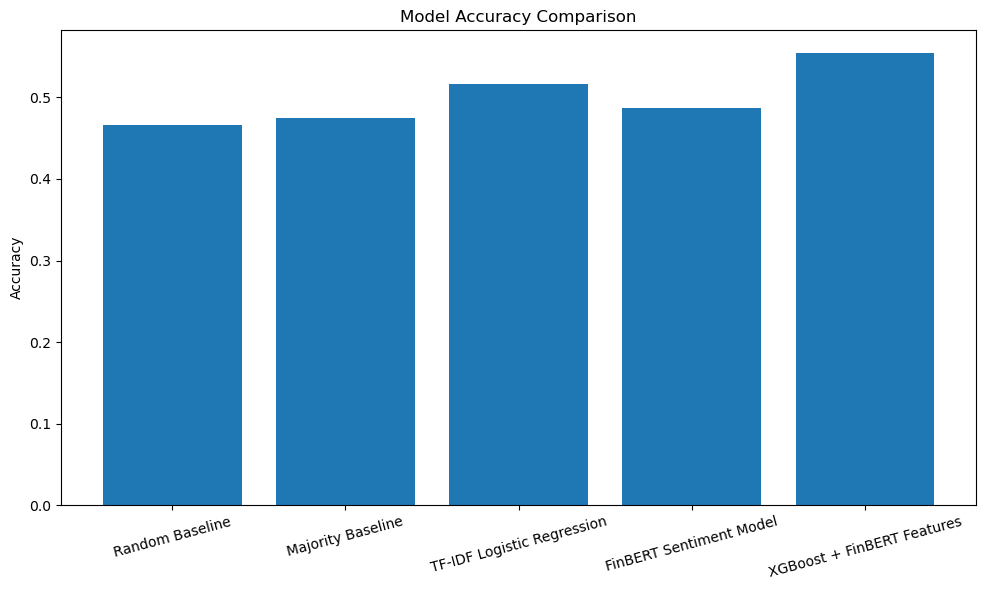

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.xticks(rotation=15)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.tight_layout()
plt.show()

## 8.2 ROC-AUC Comparison

ROC-AUC was used to evaluate each model’s ability to discriminate between positive and negative future Bitcoin price movement.

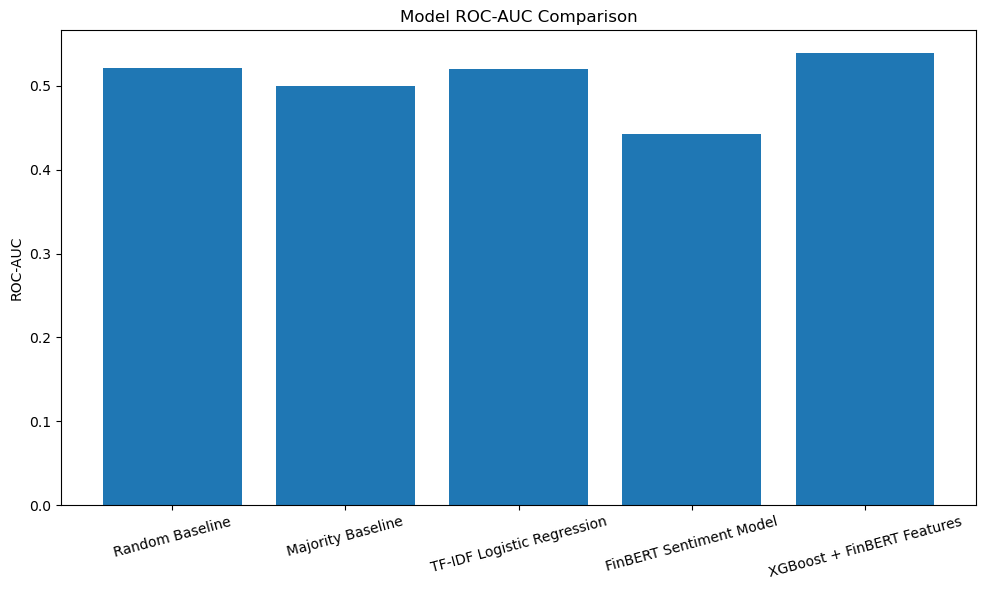

In [37]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_df["Model"],
    comparison_df["ROC-AUC"]
)

plt.xticks(rotation=15)
plt.ylabel("ROC-AUC")
plt.title("Model ROC-AUC Comparison")

plt.tight_layout()
plt.show()

## 8.3 FinBERT Sentiment Distribution

This figure shows the distribution of sentiment classifications assigned by FinBERT across the news headline dataset.

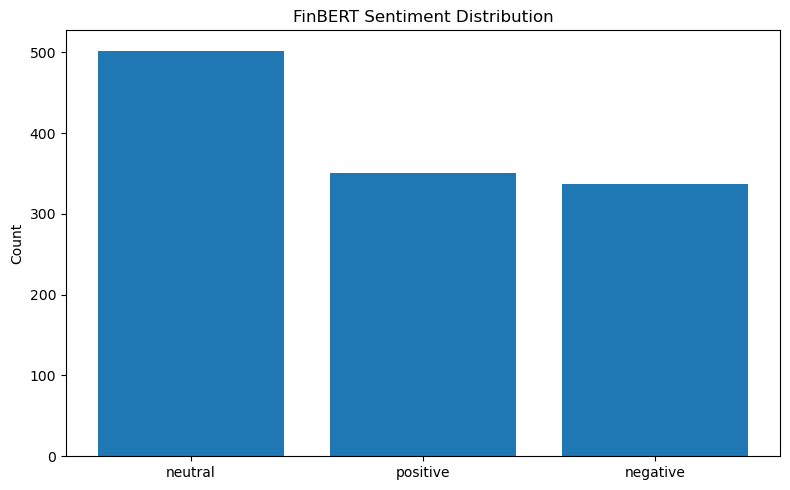

In [38]:
sentiment_counts = df["finbert_label"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.ylabel("Count")
plt.title("FinBERT Sentiment Distribution")

plt.tight_layout()
plt.show()

## 8.4 XGBoost Feature Importance

This figure shows the relative importance of the FinBERT-derived sentiment features used by the XGBoost classifier.

<Figure size 800x500 with 0 Axes>

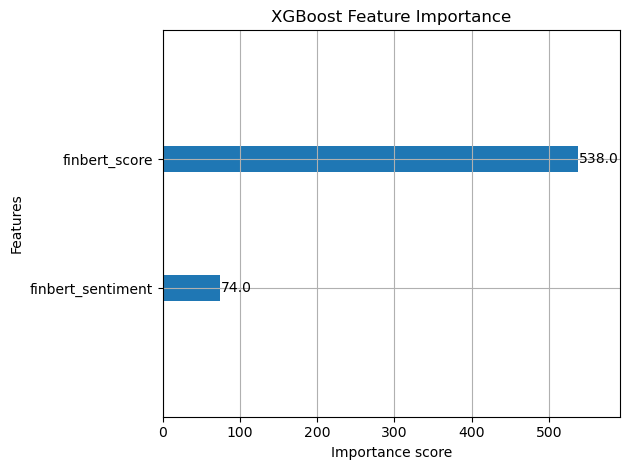

In [40]:
from xgboost import plot_importance

plt.figure(figsize=(8, 5))

plot_importance(xgb_model)

plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("final_btc_news_dataset_with_finbert.csv")

print(df.shape)
print(df.columns)

(1190, 10)
Index(['headline', 'published', 'link', 'price_t', 'price_t_plus_60',
       'return_1h', 'up_1h', 'finbert_label', 'finbert_score',
       'finbert_sentiment'],
      dtype='object')


# 9. Error Analysis & Additional Experiments

## 9.1 Big News vs Small News

This experiment investigates whether longer cryptocurrency news headlines are associated with larger subsequent Bitcoin price movements.

Headline length was used as a simple proxy for news size, with the median headline length used to divide observations into two groups: "Large" and "Small" news events. The absolute 1-hour Bitcoin return was then calculated for each group to measure the magnitude of market reaction, regardless of direction.

The purpose of this analysis is to determine whether more extensive news headlines appear to generate stronger short-term market responses than shorter headlines.

HEADLINE LENGTH ANALYSIS

In [15]:
# HEADLINE LENGTH ANALYSIS

df["headline_length"] = df["headline"].str.len()

print(df["headline_length"].describe())

count    1190.000000
mean       77.717647
std        15.440140
min        17.000000
25%        70.000000
50%        79.000000
75%        87.000000
max       135.000000
Name: headline_length, dtype: float64


In [16]:
# HEADLINE LENGTH ANALYSIS

median_length = df["headline_length"].median()

df["news_size"] = (
    df["headline_length"] > median_length
).map({
    True: "Large",
    False: "Small"
})

print(df["news_size"].value_counts())

news_size
Small    606
Large    584
Name: count, dtype: int64


In [17]:
# PRICE REACTION BY NEWS SIZE

df["abs_return_1h"] = abs(df["return_1h"])

print(
    df.groupby("news_size")["abs_return_1h"]
      .mean()
      .sort_values(ascending=False)
)

news_size
Small    0.003501
Large    0.003161
Name: abs_return_1h, dtype: float64


## 9.2 Volatility Regime Analysis

This experiment investigates whether the characteristics of cryptocurrency news differ during periods of high and low Bitcoin market volatility.

To achieve this, the absolute 1-hour Bitcoin return was calculated for each news event. Headlines associated with returns above the 75th percentile were classified as occurring during a high-volatility regime, while all remaining observations were classified as low-volatility.

This analysis aims to explore whether certain types of sentiment are more prevalent during periods of elevated market activity and whether news appears to have a different relationship with Bitcoin price movements under varying volatility conditions.

In [18]:
# HIGH VS LOW VOLATILITY PERIODS

df["abs_return_1h"] = abs(df["return_1h"])

threshold = df["abs_return_1h"].quantile(0.75)

df["volatility_regime"] = (
    df["abs_return_1h"] > threshold
).map({
    True: "High",
    False: "Low"
})

print(df["volatility_regime"].value_counts())

volatility_regime
Low     892
High    298
Name: count, dtype: int64


In [19]:
# SENTIMENT BY VOLATILITY REGIME

sentiment_volatility = pd.crosstab(
    df["volatility_regime"],
    df["finbert_label"],
    normalize="index"
)

print(sentiment_volatility.round(3))

finbert_label      negative  neutral  positive
volatility_regime                             
High                  0.279    0.419     0.302
Low                   0.285    0.423     0.293


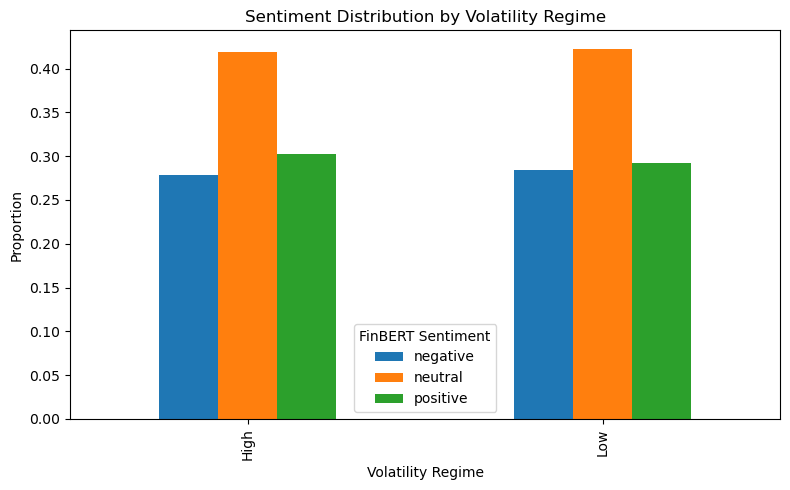

In [24]:
# SENTIMENT DISTRIBUTION BY VOLATILITY

sentiment_volatility.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sentiment Distribution by Volatility Regime")
plt.ylabel("Proportion")
plt.xlabel("Volatility Regime")
plt.legend(title="FinBERT Sentiment")

plt.tight_layout()
plt.show()

### Findings

The sentiment distribution was highly similar across both high- and low-volatility regimes. Neutral headlines represented the largest category in both groups, accounting for approximately 42% of observations. Positive and negative sentiment proportions were also nearly identical between regimes.

These results suggest that headline sentiment alone is insufficient to explain periods of elevated Bitcoin volatility. While sentiment may contribute to market behaviour, broader market conditions and external factors likely play a significant role in determining short-term price fluctuations.